关于本门**数值线性代数（Numerical Linear Algebra）**课程的概览，见[这篇博文](http://www.fast.ai/2017/07/17/num-lin-alg/)。课程最初在[旧金山大学分析学硕士（University of San Francisco MS in Analytics）](https://www.usfca.edu/arts-sciences/graduate-programs/analytics)项目中开设。讲课视频[在 YouTube 上](https://www.youtube.com/playlist?list=PLtmWHNX-gukIc92m1K0P6bIOnZb-mg0hY)（注意笔记本编号与视频编号并不一一对应，因为有些笔记本内容超过一个视频才讲完）。

课程相关问题可在 [fast.ai 论坛](http://forums.fast.ai/c/lin-alg)提问。

# 1. 我们为何在此？（Why are we here?）

**说明：后续课节的代码量会比本课多得多。**

## 为何要学数值线性代数（Numerical Linear Algebra）？

**本课核心问题**：如何在**可接受的速度（speed）**与**可接受的精度（accuracy）**下完成矩阵计算？

20 世纪科学与工程领域[十大算法（Top 10 Algorithms）](http://www.cs.fsu.edu/~lacher/courses/COT4401/notes/cise_v2_i1/index.html)列表中包括：以**矩阵分解（matrix decompositions）**处理线性代数的方法；还包括我们将要讲的 **QR 算法（QR algorithm）**，以及我们会见到例子的 **Krylov 迭代法（Krylov iterative methods）**。（另见[另一种归纳](https://nickhigham.wordpress.com/2016/03/29/the-top-10-algorithms-in-applied-mathematics/)）

<img src="images/top10.png" alt="" style="width: 30%"/>

（来源：[Top 10 Algorithms](http://www.cs.fsu.edu/~lacher/courses/COT4401/notes/cise_v2_i1/guest.pdf)）

### 20 世纪科学与工程领域十大算法（Top 10 Algorithms）

以下名单出自 *Computing in Science & Engineering* 2000 年 1/2 月号的客座编者按（Jack Dongarra、Francis Sullivan 等），按**算法出现的大致年代**排列，并非严格意义上的「第一名到第十名」。

1. **Metropolis 算法（蒙特卡罗，~1946）**  
   用随机游走与接受/拒绝准则在高维空间抽样，估计积分与期望值；现代 **MCMC**、统计物理与贝叶斯计算都建立在这类思想上。

2. **单纯形法（Simplex Method，线性规划，1947）**  
   在线性约束下沿可行域多面体的顶点和边移动，逐步优化目标函数；运筹、调度与资源分配中的经典线性规划求解器。

3. **Krylov 子空间迭代（~1950）**  
   只做矩阵–向量乘法，在由 $b, Ab, A^2b, \ldots$ 张成的子空间里构造近似解；共轭梯度、Lanczos 等都属于这一类，适合大规模稀疏方程与特征问题。**本课会见到。**

4. **矩阵计算的分解思路（Decompositional Approach，~1951）**  
   把矩阵写成更简单因子（如 LU、Householder 变换链等）的乘积，使解方程组、求逆、特征值等变成稳定、模块化的步骤。**本课主线之一。**

5. **Fortran 优化编译器（~1957）**  
   Backus 团队把自动向量化、寄存器分配、循环优化等系统化，让科学计算程序能高效映射到机器；深刻影响了后来的高性能语言与编译技术。

6. **QR 算法（特征值，~1959）**  
   反复做 QR 分解并重乘，把矩阵迭代到（拟）上三角形式以读出特征值；稠密矩阵特征值计算的标杆方法之一。**本课会讲到。**

7. **快速排序 Quicksort（~1962）**  
   分治：选枢轴分区、递归排序子数组；平均效率高，思想影响了大量分治与随机化算法。

8. **快速傅里叶变换 FFT（~1965）**  
   把离散傅里叶变换从 $O(n^2)$ 降到 $O(n\log n)$；信号与图像处理、谱方法、卷积与多项式乘法的核心工具。

9. **整数关系探测（Integer Relation Detection，~1977）**  
   在浮点近似下寻找整数系数，使若干常数的整系数线性组合接近零；**PSLQ** 等算法用于实验数学与「反推」闭式解。

10. **快速多极子方法 FMM（~1987）**  
    把远距离相互作用用多极/局部展开成组近似，显著降低 $N$ 体问题的复杂度；静电、引力与边界元类问题中的关键技术。

为矩阵计算选择或设计算法时，要记住四个方面：
- **内存使用（Memory Use）**
- **速度（Speed）**
- **精度（Accuracy）**
- **可扩展性/并行化（Scalability/Parallelization）**

这些方面之间常常需要权衡（trade-offs）。

### 动机（Motivation）

矩阵无处不在——能放进 **Excel** 表格的东西都可以看成矩阵，语言和图像也可以用矩阵表示。了解矩阵算法有哪些选择、如何在各种折衷中取舍，会对你的解法产生巨大影响。例如，**近似（approximate）**矩阵计算往往可以比精确计算快成千上万倍。

不仅要熟悉现有**库（libraries）**里有什么，还要理解它们**如何工作**。因为很多时候你可以对算法做库里不支持的变体，从而获得所需的性能或精度。此外，这一领域目前发展很快，尤其在**深度学习（deep learning）**、**推荐系统（recommendation systems）**、**近似算法（approximate algorithms）**与**图分析（graph analytics）**等方向，常有最新结果能显著改变你的项目，却尚未进入你用的库。

真正理解算法如何运作，既有助于**调试（debug）**，也有助于**加速（accelerate）**你的方案。 

## 矩阵计算（Matrix Computations）

矩阵计算主要有两大类，会以多种方式组合使用：
- **矩阵与张量积（Matrix and tensor products）**
- **矩阵分解（Matrix decompositions）**

概括地说：我们要把矩阵**合在一起**，再**拆开**！

### 矩阵与张量积（Matrix and Tensor Products）

#### 矩阵–向量积（Matrix-Vector Products）

下面的矩阵给出在 **1 年内**从一种**健康状态（health state）**转移到另一种状态的概率。若某群体当前分布为：
- 85% **无症状（asymptomatic）**
- 10% **有症状（symptomatic）**
- 5% **艾滋病（AIDS）**
- 0% **死亡（death）**

一年后各状态各占百分之多少？

<img src="images/markov_health.jpg" alt="健康状态转移（Markov）" style="width: 70%"/>

（来源：[马尔可夫链的概念（Concepts of Markov Chains）](https://www.youtube.com/watch?v=0Il-y_WLTo4)）

#### 答案（Answer）

In [6]:
import numpy as np

In [ ]:
# 练习：用 Numpy 计算上题答案

array([[ 0.765 ],
       [ 0.1525],
       [ 0.0645],
       [ 0.018 ]])

In [ ]:
# 回答

#### 矩阵–矩阵积（Matrix-Matrix Products）

<img src="images/shop.png" alt="商店线性代数示例（shop）" style="width: 100%"/>（来源：[线性代数工具的若干简单实际应用（Several Simple Real-world Applications of Linear Algebra Tools）](https://www.mff.cuni.cz/veda/konference/wds/proc/pdf06/WDS06_106_m8_Ulrychova.pdf)）

#### 答案（Answer）

In [23]:
# 练习：用 Numpy 计算上题答案


array([[ 50. ,  49. ],
       [ 58.5,  61. ],
       [ 43.5,  43.5]])

#### 图像数据（Image Data）

图像可以用矩阵表示。

<img src="images/digit.gif" alt="手写数字（digit）" style="width: 55%"/>

（来源：[Adam Geitgey](https://medium.com/@ageitgey/machine-learning-is-fun-part-3-deep-learning-and-convolutional-neural-networks-f40359318721)）


#### 卷积（Convolution）

**卷积（Convolutions）**是**卷积神经网络（CNNs, convolutional neural networks）**的核心，而 CNN 属于**深度学习（deep learning）**；近年来图像识别（image recognition）的巨大进展很大程度上归功于卷积。卷积也越来越多用于语音，例如 [Facebook AI](https://code.facebook.com/posts/1978007565818999/a-novel-approach-to-neural-machine-translation/) 在语音翻译上的结果比 **RNN（循环神经网络）**（当前语音翻译中最流行的做法之一）快约 9 倍。

在图像分类上，计算机的准确率已超过人类。

<img src="images/sportspredict.jpeg" alt="ImageNet" style="width: 80%"/>
  （来源：[Andrej Karpathy](http://karpathy.github.io/2014/07/03/feature-learning-escapades/)）

<img src="images/InsideImagenet.png" alt="ImageNet" style="width: 80%"/>
  （来源：[Nvidia](https://blogs.nvidia.com/blog/2014/09/07/imagenet/)）

可以把卷积看成一种特殊的**矩阵乘法（matrix product）**。

下面三张图均来自 fast.ai 学员的一篇优秀博文 [从不同视角看 CNN（CNNs from Different Viewpoints）](https://medium.com/impactai/cnns-from-different-viewpoints-fab7f52d159c)：

卷积对图像的每个局部施加**滤波器（filter）**：
<img src="images/cnn1.png" alt="CNNs" style="width: 40%"/>

**神经网络视角（Neural Network Viewpoint）**：
<img src="images/cnn2.png" alt="CNNs" style="width: 40%"/>

**矩阵乘法视角（Matrix Multiplication Viewpoint）**：
<img src="images/cnn3.png" alt="CNNs" style="width: 80%"/>

在[此笔记本](convolution-intro.ipynb)中可看如何用卷积做**边缘检测（edge detection）**（原出自 [fast.ai 深度学习课程（fast.ai Deep Learning Course）](http://course.fast.ai/)）。 

### 矩阵分解（Matrix Decompositions）

本课程每天都会涉及**矩阵分解（Matrix Decompositions）**；下面例子将在后续课节中展开：

- **主题建模（Topic Modeling）**（**NMF** 与 **SVD**；SVD 会用到 **QR**）一组文档可用**词项–文档矩阵（term-document matrix）**表示

<img src="images/document_term.png" alt="term-document matrix" style="width: 70%"/>

（来源：[信息检索导论（Introduction to Information Retrieval）](http://player.slideplayer.com/15/4528582/#)）

<img src="images/nmf_doc.png" alt="NMF on documents" style="width: 70%"/>

（来源：[NMF 教程（NMF Tutorial）](http://perso.telecom-paristech.fr/~essid/teach/NMF_tutorial_ICME-2014.pdf)）

- **背景去除（Background removal）**（**稳健 PCA（robust PCA）**，使用**截断 SVD（truncated SVD）**）
![背景去除（background removal）](images/surveillance3.png)

- **谷歌 PageRank 算法（Google's PageRank Algorithm）**（**特征分解（eigen decomposition）**）

<img src="images/page_rank_graph.png" alt="PageRank" style="width: 70%"/>
  （来源：[What is in PageRank?](http://computationalculture.net/article/what_is_in_pagerank)）

- 其他分解及部分应用列表见 [matrix factorization jungle](https://sites.google.com/site/igorcarron2/matrixfactorizations)

## 精度（Accuracy）

### 浮点算术（Floating Point Arithmetic）

要理解**精度（accuracy）**，首先要看**计算机（有限、离散）如何存储数（无限、连续）**。

#### 练习（Exercise）

先看下面的函数 $f$。在运行代码之前，先在纸上写出 $x_1 = f(\frac{1}{10})$ 应等于多少；再把结果代回 $f$，算 $x_2 = f(x_1)$，继续在纸上迭代 10 步。

本例取自 Greenbaum 与 Chartier 所著 *Numerical Methods* 第 107 页。

In [1]:
def f(x):
    if x <= 1/2:
        return 2 * x
    if x > 1/2:
        return 2*x - 1

只有在你已经写下自己认为应有的结果之后，再运行下面代码：

In [2]:
x = 1/10
for i in range(80):
    print(x)
    x = f(x)

0.1
0.2
0.4
0.8
0.6000000000000001
0.20000000000000018
0.40000000000000036
0.8000000000000007
0.6000000000000014
0.20000000000000284
0.4000000000000057
0.8000000000000114
0.6000000000000227
0.20000000000004547
0.40000000000009095
0.8000000000001819
0.6000000000003638
0.2000000000007276
0.4000000000014552
0.8000000000029104
0.6000000000058208
0.20000000001164153
0.40000000002328306
0.8000000000465661
0.6000000000931323
0.20000000018626451
0.40000000037252903
0.8000000007450581
0.6000000014901161
0.20000000298023224
0.4000000059604645
0.800000011920929
0.6000000238418579
0.20000004768371582
0.40000009536743164
0.8000001907348633
0.6000003814697266
0.20000076293945312
0.40000152587890625
0.8000030517578125
0.600006103515625
0.20001220703125
0.4000244140625
0.800048828125
0.60009765625
0.2001953125
0.400390625
0.80078125
0.6015625
0.203125
0.40625
0.8125
0.625
0.25
0.5
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


出了什么问题？

#### 问题所在：数学连续且无限，而计算机离散且有限

计算机表示数的两大限制：
1. 不能任意大或任意小  
2. 表示值之间必有**间隔（gaps）**

我们必须关心**精度（accuracy）**，是因为计算机无法存储无限精确的数。可以构造出结果严重错误的计算（尤其在同一操作重复很多次时，每步都可能**放大误差（multiply the error）**）。

计算机如何存储数：

<img src="images/fpa.png" alt="浮点（floating point）" style="width: 60%"/>

**尾数（mantissa）**也可称为**有效数字部分（significand）**。

**IEEE 双精度（IEEE Double precision）**算术：
- 数可大到约 $1.79 \times 10^{308}$，小到约 $2.23 \times 10^{-308}$。
- 区间 $[1,2]$ 由如下离散子集表示：
$$1, \: 1+2^{-52}, \: 1+2 \times 2^{-52},\: 1+3 \times 2^{-52},\: \ldots, 2$$

- 区间 $[2,4]$ 表示为：
$$2, \: 2+2^{-51}, \: 2+2 \times 2^{-51},\: 2+3 \times 2^{-51},\: \ldots, 4$$


**单精度（float）**与**双精度（double）**的间距并非均匀：

<img src="images/fltscale-wh.png" alt="浮点间距示意（floating point）" style="width: 100%"/>

来源：[What you never wanted to know about floating point but will be forced to find out](http://www.volkerschatz.com/science/float.html)

**机器精度（Machine Epsilon）**

1 与下一个可表示较大数之间距离的一半；具体值因机器而异。**IEEE 双精度（double precision）**标准规定 $$ \varepsilon_{machine} = 2^{-53} \approx 1.11 \times 10^{-16}$$

**浮点算术（Floating Point Arithmetic）**的两条重要性质：

- 实数 $x$ 与其最近**浮点近似（floating point approximation）** $fl(x)$ 之差，在**相对意义（relative terms）**下总小于 $\varepsilon_{machine}$。存在某 $\varepsilon$，满足 $\lvert \varepsilon \rvert \leq \varepsilon_{machine}$，使得 $$fl(x)=x \cdot (1 + \varepsilon)$$

- 设 $*$ 为任一运算（$+, -, \times, \div$），$\circledast$ 为其**浮点版本（floating point analogue）**，则
    $$ x \circledast y = (x * y)(1 + \varepsilon)$$
对某个 $\lvert \varepsilon \rvert \leq \varepsilon_{machine}$ 成立。  
即：每一步浮点运算在**相对误差（relative error）**上至多相当于乘以 $(1+\varepsilon)$，且 $\lvert\varepsilon\rvert\leq\varepsilon_{machine}$。

#### 历史（History）

事后看浮点算术似乎理所当然，但历史上存储数的方式非常多：
- **定点算术（fixed-point arithmetic）**
- **对数与半对数数系（logarithmic and semilogarithmic number systems）**
- **连分数（continued-fractions）**
- **有理数（rational numbers）**
- **有理数字符串（可能无限）（possibly infinite strings of rational numbers）**
- **层–指数数系（level-index number systems）**
- **固定斜杠与浮动斜杠数系（fixed-slash and floating-slash number systems）**
- **2-adic 数（2-adic numbers）**

参考文献见 [Handbook of Floating-Point Arithmetic](http://www.springer.com/gp/book/9780817647049) 的[第 1 章（免费）](https://perso.ens-lyon.fr/jean-michel.muller/chapitre1.pdf)。是的，光浮点就有整整 16 章的书！

**浮点算术（Floating Point Arithmetic）**简史时间线：
- 约公元前 1600 年：巴比伦 **60 进制（radix-60）**系统被视为最早浮点形式（Donald Knuth）。表示 **60 进制浮点的有效数（significand）**（若两数之比为 60 的幂，则视为同一表示）
- 1630：**计算尺（Slide rule）**。只操作**有效数（significands）**（**10 进制 radix-10**）
- 1914：Leonardo Torres y Quevedo 描述用机电方式实现 **Babbage 分析机（Analytical Engine）**并带**浮点算术（Floating Point Arithmetic）**
- 1941：首个真正现代实现——**Konrad Zuse** 的 **Z3** 计算机。采用 **2 进制（radix-2）**，14 位有效数、7 位指数、1 位符号
- 1985：**IEEE 754-1985** 二进制浮点标准发布，提高了精度、可靠性与可移植性。[William Kahan](https://people.eecs.berkeley.edu/~wkahan/) 起关键作用

「在计算机上近似实数的方式曾有许多种……然而，**浮点算术（floating-point arithmetic）**仍是现代计算机表示实数**最常用**的手段。用有限集合（“机器数（machine numbers）”）去模拟无限、连续的集合（实数）并非易事：**必须在速度、精度、动态范围、易用性、实现难度与内存之间做出巧妙折衷**。看来，在参数（**进制（radix）**、**精度（precision）**、**极值指数（extremal exponents）** 等）选取得当时，浮点算术对大多数**数值应用（numerical applications）**都是一种很好的折衷。」

尽管对计算机而言 **2 进制（binary）**作为**进制（radix）**似乎已是明显选择，历史上仍用过多种进制：

- **radix-8**：早期机器 **PDP-10**、**Burroughs 570/6700**
- **radix-16**：**IBM 360**
- **radix-10**：金融计算、计算器、**Maple**
- **radix-3**：苏联 **SETUN** 计算机（1958）。优点：在最大可表示数为 $\beta^p-1$ 固定时，最小化 $\beta\times p$（符号数 $\times$ 位数）；**舍入（Rounding）**等于**截断（truncation）**
- **radix-2**：最常见。原因：易实现；研究表明（含**隐式前导位 implicit leading bit**）其最坏或平均精度优于其他进制

### 条件数与稳定性（Conditioning and Stability）

由于无法在计算机上**精确**表示数（存储有限、**浮点（floating point）**结构下数之间有间隔），需要了解**输入的小扰动（perturbations）如何影响输出**。

**「稳定算法（stable algorithm）对几乎正确的问题给出几乎正确的答案。」**——Trefethen

**条件数/病态性（Conditioning）**：数学问题本身在扰动下的性态（例如**最小二乘（least squares）**）

**稳定性（Stability）**：在计算机上求解该问题的**算法（algorithm）**在扰动下的性态（例如最小二乘算法、**Householder**、**回代（back substitution）**、**高斯消元（gaussian elimination）**）

示例：矩阵的特征值（Eigenvalues of a Matrix）

In [37]:
import scipy.linalg as la 

A = np.array([[1., 1000], [0, 1]])
B = np.array([[1, 1000], [0.001, 1]])

print(A)

print(B)

[[    1.  1000.]
 [    0.     1.]]
[[    1.     1000.   ]
 [    0.001     1.   ]]


In [30]:
np.set_printoptions(suppress=True, precision=4)

In [ ]:
wA, vrA = la.eig(A)
wB, vrB = la.eig(B)

wA, wB

**复习：浮点算术（Floating Point Arithmetic）的两条性质**

- 实数 $x$ 与其最近浮点近似 $fl(x)$ 之差在相对意义下总小于 $\varepsilon_{machine}$。

- 浮点下 $+, -, \times, \div$ 每一步在相对误差上至多相当于 $\varepsilon_{machine}$。

后续将见到的例子：
- **经典与修正 Gram–Schmidt（Classical vs Modified Gram-Schmidt）**的精度
- **Gram–Schmidt** 与 **Householder**（两种求 **QR 分解（QR factorization）**的方式）所得向量**正交性（orthogonal）**如何
- **方程组的条件（Condition of a system of equations）**

### 近似精度（Approximation accuracy）

大规模场景下很少需要**极高精度**的矩阵计算。事实上常在做某种**机器学习（machine learning）**，略低精度反而有助于抑制**过拟合（overfitting）**。

若能接受精度略降，往往可用**近似算法（approximate algorithms）**把速度提高若干数量级（并/或减少内存）。这类算法通常以一定概率给出正确结果；多次重复运行一般可**成倍**提高该概率。

**示例**：**布隆过滤器（bloom filter）**可在约 **1% 误报（false positives）**下用每个元素不足 10 bit 做集合成员查询，内存常可缩小成千上万倍。

<img src="images/bloom_filter.png" alt="Bloom Filters" style="width: 60%"/>

误报可用第二阶段（**精确 exact**）校验所有候选元素来消除——对**稀有**元素很有效。例如许多浏览器用布隆过滤器维护**恶意页**集合，因被封禁网页只占全网一小部分；对过滤器命中的 URL 再向存有完整列表的**网络服务**核实即可。（详见 [bloom filter tutorial](https://llimllib.github.io/bloomfilter-tutorial/)）

### 代价高昂的错误（Expensive Errors）

*以下例子出自 Greenbaum & Chartier。*

**欧洲空间局（European Space Agency）**在 **Ariane 5** 火箭上耗资约 70 亿美元、历时约 10 年。

把 **64 位**数硬塞进 **16 位**空间会发生什么（**整数溢出 integer overflow**）：

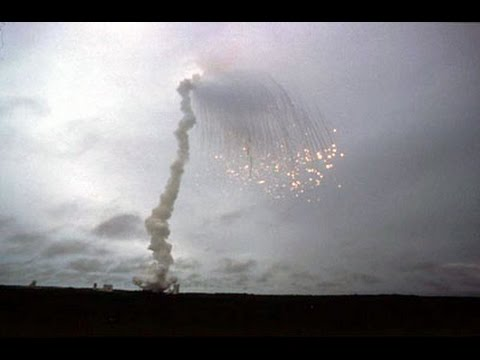

In [3]:
# 阿里安 5 失败相关视频（Ariane 5）
from IPython.display import YouTubeVideo
YouTubeVideo("PK_yguLapgA")

下面是一次让 **Intel** 损失约 **4.75 亿美元**的**浮点（floating point）**错误：

[1994 年《纽约时报》关于 Intel Pentium 缺陷的报道（NYTimes article about Intel Pentium Error）](http://www.nytimes.com/1994/11/24/business/company-news-flaw-undermines-accuracy-of-pentium-chips.html)
![报道截图（article）](images/pentium_nytimes.png)

**延伸阅读（Resources）**：浮点算术可参看 Trefethen & Bau 第 13 讲，以及 Greenbaum & Chartier 第 5 章。

## 内存使用（Memory Use）

### 稀疏与稠密（Sparse vs Dense）

上文讲了*数*如何存储，现在讲*矩阵*如何存储。节省内存（与计算）的关键之一是**不要存整个矩阵**，只存**非零元（non-zero elements）**。这叫**稀疏存储（sparse storage）**，适合**稀疏矩阵（sparse matrices）**——即大部分元素为 0 的矩阵。

<img src="images/sparse.png" alt="稀疏矩阵（sparse）" style="width: 50%"/>

下面是**有限元（finite element）**问题中的矩阵示例，常见于工程（例如模拟飞机周围气流）。图中非零元为黑，零元为白：
<img src="images/Finite_element_sparse_matrix.png" alt="有限元稀疏矩阵（finite element）" style="width: 50%"/>

[来源 Source](https://commons.wikimedia.org/w/index.php?curid=2245335)

还有对角、三对角、Hessenberg、三角等结构化矩阵（structured matrix），各自呈现特定稀疏模式，可用来进一步减内存与计算量。

与稀疏矩阵相对的是**稠密矩阵（dense matrix）**及**稠密存储（dense storage）**：矩阵大多为非零，且每个元素都显式存储。由于稀疏矩阵既常见又有用，**数值线性代数（numerical linear algebra）**注重在计算中尽可能**保持稀疏性（maintaining sparsity）**。

## 速度（Speed）

速度差异来自多方面，尤其包括：
- **计算复杂度（Computational complexity）**
- **向量化（Vectorization）**
- **扩展到多核与多节点（Scaling to multiple cores and nodes）**
- **局部性（Locality）**

### 计算复杂度（Computational complexity）

若对**计算复杂度（computational complexity）**与 **$\mathcal{O}$ 记号（notation）**不熟，可读 [Interview Cake](https://www.interviewcake.com/article/java/big-o-notation-time-and-space-complexity) 与 [Codecademy 练习](https://www.codecademy.com/courses/big-o/0/3)。算法复杂度通常按矩阵**行数、列数**表述，例如某算法为 $\mathcal{O(n^2m)}$。

### 向量化（Vectorization）

现代 **CPU** 与 **GPU** 可在单核上同时对多个元素执行同一操作，例如一步对向量中 4 个 **float** 求指数。这叫 **SIMD**。你通常不会手写 **SIMD** 代码（往往要用汇编或 **C** 的 **intrinsics**），而是使用 **numpy** 等库中的向量化运算；这些库又依赖专门调优的底层线性代数 **API**，尤其是 **BLAS** 与 **LAPACK**。

#### 矩阵计算软件包：BLAS 与 LAPACK（Matrix Computation Packages）

[BLAS（Basic Linear Algebra Subprograms，基本线性代数子程序）](http://www.netlib.org/blas/)：规定底层矩阵与向量算术运算的接口，是基本向量/矩阵运算的标准构件。**BLAS** 源于 1979 年的 **Fortran** 库。实现例子包括：**ACML**、**ATLAS**、**Intel MKL（Math Kernel Library）**、**OpenBLAS** 等。

[LAPACK](http://www.netlib.org/lapack/) 用 **Fortran** 编写，提供解线性方程组、**特征值（eigenvalue）**问题、**奇异值（singular value）**问题等例程；含 **LU**、**Cholesky**、**QR**、**SVD**、**Schur** 等**矩阵分解（Matrix factorizations）**。处理**稠密（Dense）**与**带状（banded）**矩阵，不处理一般**稀疏（sparse）**矩阵；支持实数/复数、单/双精度。

1970–1980 年代：**EISPACK**（特征值例程）与 **LINPACK**（线性方程与线性最小二乘例程）库。

**LAPACK 最初目标**：让 **LINPACK**（原文误写 LINAPCK）与 **EISPACK** 在**共享内存（shared-memory）**向量机与并行处理器上高效运行，并在现代**基于缓存（cache-based）**体系结构上利用 **cache**（1992 年初版）。**EISPACK** 与 **LINPACK** 忽视多层**存储层次（memory hierarchies）**，数据搬运耗时过多。

**LAPACK** 使用高度优化的**分块运算（block operations）**实现（需在每种机器上分别实现）；设计上尽可能把计算交给 **BLAS** 完成。

### 局部性（Locality）

较慢的访存方式（例如经 **互联网 internet**）可比最快方式（例如从**寄存器 register** 读）慢约十亿倍；但快存储比慢存储少得多。因此数据一旦进入快存储，应尽量当场做完所需计算，而不是每次需要时反复从慢层加载。此外，对多数存储类型，访问**相邻（next to each other）**数据更快，故应尽早利用已知即将用到的邻近数据。这两点统称**局部性（locality）**。

#### 不同存储类型的速度（Speed of different types of memory）

下面是*人人都该心里有数*的一些数字（出自 [Jeff Dean](http://static.googleusercontent.com/media/research.google.com/en/us/people/jeff/stanford-295-talk.pdf) 的著名演讲）：
- **L1 cache** 访问约 0.5 ns
- **L2 cache** 访问约 7 ns
- **主存/Main memory（RAM）** 访问约 100 ns
- **1 Gbps** 网络发送 2 KB 约 20,000 ns
- 顺序从内存读 1 MB 约 250,000 ns
- 同一**数据中心（datacenter）**内往返约 500,000 ns
- **磁盘寻道（Disk seek）** 约 10,000,000 ns
- 顺序从网络读 1 MB 约 10,000,000 ns
- 顺序从磁盘读 1 MB 约 30,000,000 ns
- 数据包 CA→荷兰→CA 约 150,000,000 ns

另有更新、可交互的[版本](https://people.eecs.berkeley.edu/~rcs/research/interactive_latency.html)，含这些数字随时间变化的时间线。

**要点**：越往下的存储类型，延迟通常（至少）比上一层差一个**数量级（order of magnitude）**。**磁盘寻道（Disk seeks）非常慢**。

该视频很好地演示了用多种方式计算照片**模糊（blur）**及各自权衡。不必纠结出现的 **C** 代码，重点看红绿动态图所展示的矩阵计算。

视频围绕名为 **Halide** 的语言，但其中问题具有普遍性。请观看约第 1–13 分钟：

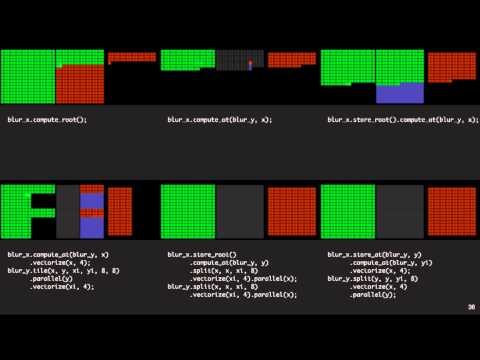

In [1]:
# Halide：图像模糊与局部性（约第 1–13 分钟）
from IPython.display import YouTubeVideo
YouTubeVideo("3uiEyEKji0M")

**局部性（Locality）**很难兼顾。可能的权衡：
- 用**冗余计算（redundant computation）**换**内存带宽（memory bandwidth）**
- 牺牲**并行度（parallelism）**以换取更好的**数据重用（reuse）**

#### 临时变量（Temporaries）

「**临时变量（temporaries）**」问题指：计算结果先写入 **RAM** 中的临时变量，再读回做下一步运算。这比把数据留在 **cache** 或**寄存器（registers）**里、在写回 **RAM** 前做完所有运算要慢许多个数量级。对 **numpy** 尤其明显：它往往为**每一个**运算或函数调用都创建临时变量。例如 $a=b\cdot c^2+ln(d)$ 会产生四个临时结果（对应四次运算/函数）。

### 扩展到多核与多节点（Scaling to multiple cores and nodes）

**可扩展性（scalability）**另有专节，但值得强调：它也直接关系速度——若无法把已有算力都用上，计算就会偏慢。

## 可扩展性 / 并行化（Scalability / parallelization）

我们常会遇到数据量超出单机**内存（memory）**或计算时间预算的情况。此时希望算法能扩展到[多核（multiple cores）](http://www.makeuseof.com/tag/processor-core-makeuseof-explains-2/)（同一台计算机内）或**节点（nodes）**（网络上的多台计算机）。本课不讨论**多节点（multi-node）**扩展，但会涉及**多核**扩展（即**并行化 parallelization**）。一般而言，**可扩展算法（scalable algorithms）**能把输入拆成小块，由不同**核/计算机（core/computer）**分别处理，最后再合并结果。